In [ ]:
## IDW Interpolation Performance Evaluation
# Last updated: 10/30/25

'''
Evaluation methodology: pointwise cross-validation check --> spatial sampling validation... at each observed location and time, sample interpolated surface and compare it to what was actually measured.
    1. harmonize timestamps (tz-naive vs tz-aware so hours actually match)
    2. reproject obs lon/lat into the grid CRS so spatial sampling hits the grid correctly
    3. sample the gridded surface at each obs point/time using xarray interpolation
    4. compute residuals (pred - obs)
    5. summarize residuals with RMSE/MAE/bias (and plots by hour/elevation/etc.)


Reflects only in-sample fit, so measuring internal consistency, not actual predicitive skill at unsampled locations.
This is more of a QA/QC diagnostic rather than a full performance evaluation!
Zhang et al., 2015: https://www.mdpi.com/2220-9964/4/4/2742

Computing
- RMSE --> overall magnitude of interpolation error
- MAE --> average absolute deviation 
- bias --> systematic over/under prediction
'''

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import rasterio as rio
import matplotlib.ticker as mticker
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.colors import TwoSlopeNorm
import geopandas as gpd
from rasterio.plot import show as rio_show
from scipy.interpolate import griddata
import matplotlib.patches as mpatches
from pyproj import Transformer
from rasterio.warp import calculate_default_transform, reproject, Resampling
import rasterio as rio

# PATHS
BASE_DIR = Path().resolve().parent

CONFIG = {
    "station_meta_csv": BASE_DIR / "Data/Stations/station_metadata_20241001_20250531.csv",
    "station_dir":      BASE_DIR / "Data/Stations",   # per-station CSVs
    "imerg_dir":        BASE_DIR / "Data/IMERG",      # parquet (wide)
    "mros_parquet":     BASE_DIR / "Data/observations/wy25_mros_obs.parquet",
    "dem_path":         BASE_DIR / "Data/elevation/DEM_1km_clipped.tif", # final clipped DEM
    "data_dir":         BASE_DIR / "outputs/hourly_pipeline",
    "out_dir":          BASE_DIR / "outputs/hourly_pipeline/evaluation/IDW_full",
    "idw_nc":           Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/IDW/hourly_predictors_1km_IDW_full.nc") # too large to store on github so saved locally and in Google Drive data folder
}

VARS = ["mros_plp_proxy", "plp", "temp_air", "temp_wet", "temp_dew", "rh"]
XNAME, YNAME, TNAME = "x", "y", "time"
OUT_DIR = Path(CONFIG["out_dir"])
DATA_DIR = Path(CONFIG["data_dir"])


# Create an evaluation subfolder for results
eval_dir = OUT_DIR / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

# Whole window:
start_time = pd.to_datetime("2024-10-01 00:00")
end_time   = pd.to_datetime("2025-05-31 23:00")

# Test window
# start_time = pd.to_datetime("2025-03-30 00:00")
# end_time   = pd.to_datetime("2025-04-02 23:00")


In [8]:
# LOAD IDW GRID 

print("\n--- Loading IDW dataset ---")
idw = xr.open_dataset(CONFIG["idw_nc"])
print(idw)
print("Variables:", list(idw.data_vars))
print("Time range:", str(idw["time"].values[0]), "→", str(idw["time"].values[-1]))

# LOAD OBSERVATION DATASETS
print("\n--- Loading observations ---")
st_hr   = pd.read_parquet(DATA_DIR / "hourly_data/stations_hourly.parquet")
imerg_hr = pd.read_parquet(DATA_DIR / "hourly_data/imerg_hourly.parquet")
mros_hr  = pd.read_parquet(DATA_DIR / "hourly_data/mros_hourly.parquet")
print("Stations:", st_hr.shape, "IMERG:", imerg_hr.shape, "MRoS:", mros_hr.shape)

# Normalize timezone before window subset
imerg_hr["hour_utc"] = pd.to_datetime(imerg_hr["hour_utc"], utc=True).dt.tz_localize(None)

imerg_window = imerg_hr[
    (imerg_hr["hour_utc"] >= start_time) &
    (imerg_hr["hour_utc"] <= end_time)
].copy()

print("\nIMERG subset time coverage:")
print(imerg_window["hour_utc"].min(), "→", imerg_window["hour_utc"].max())
print("Unique hours:", imerg_window["hour_utc"].nunique())


--- Loading IDW dataset ---
<xarray.Dataset> Size: 5GB
Dimensions:         (time: 5832, y: 251, x: 142)
Coordinates:
  * y               (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time            (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:0...
Data variables:
    temp_air        (time, y, x) float32 831MB ...
    temp_dew        (time, y, x) float32 831MB ...
    temp_wet        (time, y, x) float32 831MB ...
    rh              (time, y, x) float32 831MB ...
    mros_plp_proxy  (time, y, x) float32 831MB ...
    plp             (time, y, x) float32 831MB ...
    elev            (y, x) float32 143kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162130.9182594687 1000.0 0.0 4426426.168783374 0.0 -10...
Variab

In [9]:
# # Quick check on IMERG dataset

# # Basic metadata
# print("\n--- IMERG Hourly Data Summary ---")
# print(imerg_hr.info())
# print(f"\nTotal records: {len(imerg_hr):,}")

# # Show time coverage
# print("\nIMERG time range:")
# print("Min:", imerg_hr["hour_utc"].min())
# print("Max:", imerg_hr["hour_utc"].max())

# imerg_window = imerg_hr[
#     (imerg_hr["hour_utc"] >= start_time) &
#     (imerg_hr["hour_utc"] <= end_time)
# ].copy()


# print("\n--- IMERG subset for test window ---")
# print(imerg_window.shape)
# print(imerg_window["hour_utc"].drop_duplicates().sort_values().head(20))

# plt.figure(figsize=(6,3))
# imerg_hr["hour_utc"].hist(bins=100)
# plt.axvline(start_time, color="r", linestyle="--", label="Test start")
# plt.axvline(end_time, color="g", linestyle="--", label="Test end")
# plt.title("Distribution of IMERG Hourly Timestamps")
# plt.xlabel("Time")
# plt.ylabel("Count")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Distribution of PLP values in test window ---
# print("\n--- PLP Distribution within test window ---")

# # Subset
# imerg_window = imerg_hr[
#     (imerg_hr["hour_utc"] >= start_time) &
#     (imerg_hr["hour_utc"] <= end_time)
# ].copy()

# # Drop missing / nodata
# valid_plp = imerg_window["plp"].dropna()

# # Print summary stats
# print(valid_plp.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

# # Plot histogram
# plt.figure(figsize=(6,3))
# plt.hist(valid_plp, bins=100, color="royalblue", alpha=0.8)
# plt.xlabel("PLP value")
# plt.ylabel("Count")
# plt.title("Distribution of IMERG PLP Values (2025-03-30 → 2025-04-01)")
# plt.tight_layout()
# plt.show()


# # --- Time series of mean PLP with variability band ---
# plp_timeseries = (
#     imerg_window.groupby("hour_utc")["plp"]
#     .agg(["mean", "std"])
#     .reset_index()
# )

# plt.figure(figsize=(10,4))
# plt.plot(plp_timeseries["hour_utc"], plp_timeseries["mean"],
#          color="steelblue", lw=2, label="Mean PLP")
# plt.fill_between(
#     plp_timeseries["hour_utc"],
#     plp_timeseries["mean"] - plp_timeseries["std"],
#     plp_timeseries["mean"] + plp_timeseries["std"],
#     color="steelblue", alpha=0.2, label="±1 SD"
# )
# plt.title("IMERG PLP (%) Over Time (Test Window)")
# plt.xlabel("Time (UTC)")
# plt.ylabel("PLP (%)")
# plt.xlim(start_time, end_time)          # ← restrict to window
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()




In [10]:
# WIDE → LONG CONVERSION
def melt_obs(df, vars_, source):
    df = df.copy()
    df = df.melt(
        id_vars=["hour_utc", "lat", "lon", "elev"],
        value_vars=[v for v in vars_ if v in df.columns],
        var_name="var", value_name="obs_value"
    )
    df = df.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})
    df["source"] = source
    return df

st_long   = melt_obs(st_hr,   ["temp_air","temp_wet","temp_dew","rh"], "stations")
imerg_long= melt_obs(imerg_hr,["plp"], "imerg")
mros_long = melt_obs(mros_hr, ["mros_plp_proxy"], "mros")

obs_all = pd.concat([st_long, imerg_long, mros_long], ignore_index=True)
print(f"\nCombined observations: {obs_all.shape[0]} records")


Combined observations: 9204960 records


In [11]:
# DATETIME HANDLING
print("\n--- Checking time formats (tz-aware vs naive) ---")
print("Observation time dtype:", obs_all["time"].dtype)
print("IDW time dtype:", idw["time"].dtype)

# Ensure tz-naive alignment
obs_all["time"] = pd.to_datetime(obs_all["time"], utc=True).dt.floor("h").dt.tz_localize(None)
idw_times = pd.to_datetime(idw["time"].values).tz_localize(None)

print("Obs time example:", obs_all["time"].iloc[0])
print("IDW time example:", idw_times[0])

# Filter observations within IDW time window
obs_all = obs_all[
    (obs_all["time"] >= idw_times.min()) &
    (obs_all["time"] <= idw_times.max())
]
print(f"Filtered to {obs_all['time'].min()} → {obs_all['time'].max()}")


--- Checking time formats (tz-aware vs naive) ---
Observation time dtype: object
IDW time dtype: datetime64[ns]
Obs time example: 2024-10-01 08:00:00
IDW time example: 2024-10-01 00:00:00
Filtered to 2024-10-01 00:00:00 → 2025-05-31 23:00:00



--- Loading DEM and ensuring projected CRS ---
DEM CRS: EPSG:26911, pixel size: 1000.00 m

--- Reprojecting observation coordinates to DEM CRS ---
Obs X range: 141892.1651359729 → 410306.4481214098
Obs Y range: 3930063.706019035 → 4432428.107519504
Grid X range: 162630.9182594687 → 303630.9182594687
Grid Y range: 4175926.168783374 → 4425926.168783374


c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


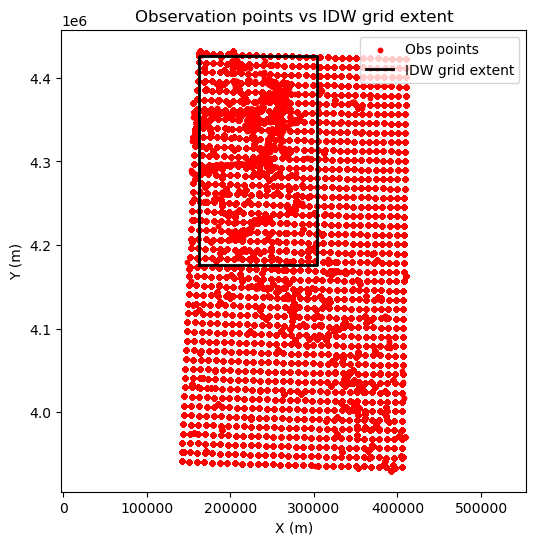

In [12]:
# REPROJECT COORDINATES TO MATCH IDW GRID CRS

# LOAD AND VERIFY DEM CRS
print("\n--- Loading DEM and ensuring projected CRS ---")

# Optional fallback projection
CONFIG["proj_fallback"] = "EPSG:26911"   # NAD83 / UTM zone 11N (units: meters)

def grid_centers(profile):
    """Compute projected x,y coordinates (in meters) for every pixel center in the DEM."""
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])

with rio.open(CONFIG["dem_path"]) as src:
    dem_crs = src.crs
    if not dem_crs or not dem_crs.is_projected:
        print(f"DEM is geographic ({dem_crs}); reprojecting to {CONFIG['proj_fallback']} ...")
        dst_crs = CONFIG["proj_fallback"]
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": dst_crs,
            "transform": transform,
            "width": width,
            "height": height
        })
        dem_data = np.empty((height, width), dtype=np.float32)
        reproject(
            source=rio.band(src, 1),
            destination=dem_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear)
        dem_profile = kwargs
        proj_crs = dst_crs
    else:
        dem_profile = src.profile
        dem_data = src.read(1)
        proj_crs = dem_crs

grid_xy = grid_centers(dem_profile)
print(f"DEM CRS: {proj_crs}, pixel size: {abs(dem_profile['transform'].a):.2f} m")

# REPROJECT OBSERVATION COORDINATES TO DEM CRS
print("\n--- Reprojecting observation coordinates to DEM CRS ---")

transformer = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
lon = obs_all["x"].values
lat = obs_all["y"].values
x_m, y_m = transformer.transform(lon, lat)
obs_all["x"] = x_m
obs_all["y"] = y_m

print("Obs X range:", obs_all["x"].min(), "→", obs_all["x"].max())
print("Obs Y range:", obs_all["y"].min(), "→", obs_all["y"].max())
print("Grid X range:", float(idw["x"].min()), "→", float(idw["x"].max()))
print("Grid Y range:", float(idw["y"].min()), "→", float(idw["y"].max()))

# VISUAL OVERLAP CHECK
plt.figure(figsize=(6,6))
plt.scatter(obs_all["x"], obs_all["y"], s=10, color="red", label="Obs points")
plt.plot(
    [idw["x"].min(), idw["x"].max(), idw["x"].max(), idw["x"].min(), idw["x"].min()],
    [idw["y"].min(), idw["y"].min(), idw["y"].max(), idw["y"].max(), idw["y"].min()],
    color="black", lw=2, label="IDW grid extent"
)
plt.legend()
plt.title("Observation points vs IDW grid extent")
plt.xlabel("X (m)"); plt.ylabel("Y (m)")
plt.axis("equal")
plt.show()


In [13]:
x_min, x_max = float(idw["x"].min()), float(idw["x"].max())
y_min, y_max = float(idw["y"].min()), float(idw["y"].max())

inside_mask = (
    (obs_all["x"] >= x_min) & (obs_all["x"] <= x_max) &
    (obs_all["y"] >= y_min) & (obs_all["y"] <= y_max)
)
coverage = inside_mask.mean() * 100
print(f"{coverage:.1f}% of observation points fall inside the IDW grid extent.")


34.2% of observation points fall inside the IDW grid extent.


In [14]:
# Subset to overlapping points
obs_all = obs_all.loc[inside_mask].copy()
print(f"Using {len(obs_all)} observations within grid extent.")

Using 3144307 observations within grid extent.


In [15]:
# SAMPLING FUNCTION --------------------------
def sample_ds_at_points(ds, points_long, var, xname="x", yname="y", tname="time"):
    """
    Sample gridded variable at observation coordinates + times (IDW dataset).
    Uses nearest-time selection with a tolerance to avoid dtype/precision mismatches.
    """
    sub = points_long.loc[points_long["var"] == var].copy()
    if sub.empty:
        print(f"No data for var {var}")
        return np.array([])

    # ensure numpy datetime64[ns] to align with xarray index dtype
    sub["time64"] = sub["time"].values.astype("datetime64[ns]")

    results = []
    valid_count = 0

    for t, g in sub.groupby("time64", sort=True):
        try:
            # first try with 30-minute tolerance
            f_time = ds[var].sel({tname: t}, method="nearest", tolerance=np.timedelta64(30, "m"))
        except Exception:
            # fall back to plain nearest if outside tolerance
            try:
                f_time = ds[var].sel({tname: t}, method="nearest")
            except Exception as e:
                # skip this hour if selection truly fails
                # print(f"{var}: could not select time {t}: {e}")
                continue

        sampled = f_time.interp(
            {xname: xr.DataArray(g[xname].values, dims="obs"),
             yname: xr.DataArray(g[yname].values, dims="obs")}
        )
        results.append(pd.Series(sampled.values, index=g.index))
        valid_count += len(g)

    if not results:
        print(f"No successful interpolations for {var}")
        return np.array([])

    preds = pd.concat(results).sort_index().values
    print(f"Sampled {valid_count} points for {var}")
    return preds


In [16]:
# COMPUTE METRICS + RESIDUALS
records, resids = [], []

for var in VARS:
    if var not in idw.data_vars:
        print(f"Variable {var} missing in dataset, skipping.")
        continue

    sub = obs_all[obs_all["var"] == var].copy()
    pred = sample_ds_at_points(idw, obs_all, var)
    sub["pred"] = pred
    sub["resid"] = sub["pred"] - sub["obs_value"]

    valid_mask = np.isfinite(sub["pred"]) & np.isfinite(sub["obs_value"])
    if valid_mask.sum() == 0:
        print(f"No valid predictions for {var}")
        continue

    rmse = np.sqrt(np.nanmean(sub.loc[valid_mask, "resid"] ** 2))
    mae  = np.nanmean(np.abs(sub.loc[valid_mask, "resid"]))
    bias = np.nanmean(sub.loc[valid_mask, "resid"])
    n    = valid_mask.sum()

    print(f"{var:15s}  RMSE={rmse:.3f}  MAE={mae:.3f}  Bias={bias:.3f}  N={n}")
    records.append({"var": var, "rmse": rmse, "mae": mae, "bias": bias, "n": n})
    resids.append(sub)

metrics = pd.DataFrame(records)
resid_df = pd.concat(resids, ignore_index=True) if resids else pd.DataFrame()

print("\nMetrics summary:")
print(metrics)

Sampled 7407 points for mros_plp_proxy
mros_plp_proxy   RMSE=6.336  MAE=1.811  Bias=0.010  N=7134
Sampled 1852440 points for plp
plp              RMSE=0.071  MAE=0.028  Bias=0.001  N=1852440
Sampled 321115 points for temp_air
temp_air         RMSE=0.638  MAE=0.248  Bias=-0.016  N=319695
Sampled 321115 points for temp_wet
temp_wet         RMSE=0.657  MAE=0.245  Bias=-0.009  N=319695
Sampled 321115 points for temp_dew
temp_dew         RMSE=0.460  MAE=0.219  Bias=-0.014  N=321115
Sampled 321115 points for rh
rh               RMSE=1.944  MAE=0.230  Bias=0.043  N=321115

Metrics summary:
              var      rmse       mae      bias        n
0  mros_plp_proxy  6.335701  1.810928  0.010459     7134
1             plp  0.070644  0.028373  0.001482  1852440
2        temp_air  0.638176  0.247626 -0.015624   319695
3        temp_wet  0.657419  0.245211 -0.009159   319695
4        temp_dew  0.460199  0.219000 -0.014197   321115
5              rh  1.943538  0.229516  0.043133   321115


Saved metrics table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\hourly_pipeline\evaluation\IDW_full\evaluation\IDW_metrics_table.png


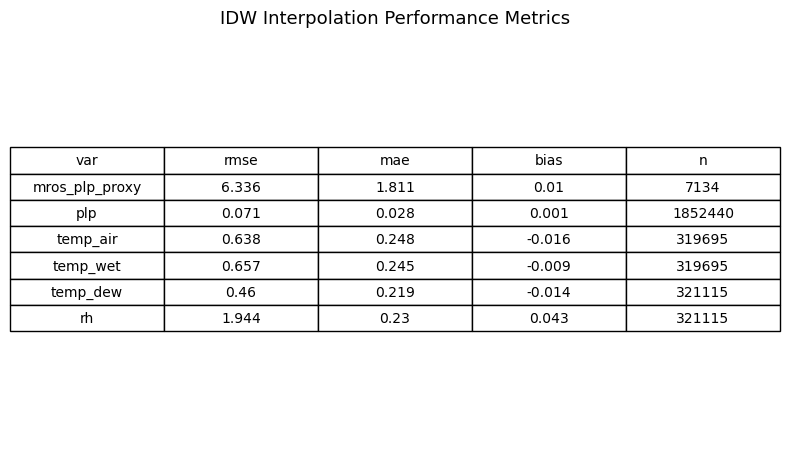

In [22]:
def plot_metrics_table(metrics_df, outdir=None, fname="IDW_metrics_table.png"):
    """
    Render metrics DataFrame as a figure table and save to disk.
    """
    df = metrics_df.copy()

    # Round for readability
    df_disp = df.copy()
    df_disp["rmse"] = df_disp["rmse"].round(3)
    df_disp["mae"]  = df_disp["mae"].round(3)
    df_disp["bias"] = df_disp["bias"].round(3)

    fig, ax = plt.subplots(figsize=(8, 0.6 * len(df_disp) + 1))
    ax.axis("off")

    table = ax.table(
        cellText=df_disp.values,
        colLabels=df_disp.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    ax.set_title(
        "IDW Interpolation Performance Metrics",
        fontsize=13,
        pad=12
    )

    plt.tight_layout()

    if outdir:
        outpath = Path(outdir) / fname
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"Saved metrics table to: {outpath}")

    plt.show()

plot_metrics_table(metrics, outdir=eval_dir)



In [18]:
# Checking

# How many unique hours per variable after sampling?
for v in ["plp", "temp_air", "temp_wet", "temp_dew", "rh", "mros_plp_proxy"]:
    sub = obs_all[obs_all["var"] == v]
    print(v, "unique hours in obs:", sub["time"].nunique())



plp unique hours in obs: 5160
temp_air unique hours in obs: 5832
temp_wet unique hours in obs: 5832
temp_dew unique hours in obs: 5832
rh unique hours in obs: 5832
mros_plp_proxy unique hours in obs: 1039


In [19]:
PALETTE = "crest"

# -------------------------------------------------------------------
# 1. RMSE BAR CHART
# -------------------------------------------------------------------
def plot_rmse_bar(metrics_df, outdir=None):
    """
    Simple RMSE bar chart per variable for IDW results.
    """
    df = metrics_df.copy().sort_values("rmse")
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x="var", y="rmse", color="steelblue")
    plt.title("IDW RMSE by Variable")
    plt.ylabel("RMSE")
    plt.xlabel("Variable")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if outdir:
        plt.savefig(Path(outdir) / "idw_rmse_by_variable.png", dpi=250)
    plt.show()


# -------------------------------------------------------------------
# 2. HEATMAP OF RMSE BY ELEVATION BAND
# -------------------------------------------------------------------
def plot_rmse_heatmap_by_elev(resid_df, outdir=None, bins=(0,1500,2500,4000)):
    """
    Show RMSE variation by elevation band and variable (IDW only).
    """
    df = resid_df.dropna(subset=["elev"])
    df["elev_band"] = pd.cut(df["elev"], bins=bins, include_lowest=True)
    rmse_stats = (
        df.groupby(["var", "elev_band"])
          .agg(rmse=("resid", lambda x: np.sqrt(np.nanmean(x**2))))
          .reset_index()
    )
    pivot = rmse_stats.pivot(index="var", columns="elev_band", values="rmse")

    plt.figure(figsize=(7,4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlBu_r", linewidths=0.4,
    # sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm_r", linewidths=0.4,
                cbar_kws={"label": "RMSE"})
    plt.title("IDW RMSE by Elevation Band")
    plt.xlabel("Elevation band (m)")
    plt.ylabel("Variable")
    plt.tight_layout()
    if outdir:
        plt.savefig(Path(outdir) / "idw_rmse_heatmap_by_elev.png", dpi=250)
    plt.show()


# -------------------------------------------------------------------
# 3. TEMPORAL RMSE TRENDS BY HOUR
# -------------------------------------------------------------------
def plot_rmse_by_hour(resid_df, outdir=None):
    """
    RMSE as a function of hour-of-day for each variable.
    Helps identify diurnal structure in interpolation errors.
    """
    df = resid_df.dropna(subset=["time", "resid"])
    df["hour"] = pd.to_datetime(df["time"]).dt.hour
    hourly_rmse = (
        df.groupby(["var", "hour"])
          .agg(rmse=("resid", lambda x: np.sqrt(np.nanmean(x**2))))
          .reset_index()
    )

    g = sns.FacetGrid(hourly_rmse, col="var", col_wrap=3, height=4, sharey=False)
    g.map_dataframe(sns.lineplot, x="hour", y="rmse", lw=2, color="steelblue", marker="o")
    g.set_axis_labels("Hour (UTC)", "RMSE")
    g.set_titles("{col_name}")
    g.set(xlim=(0,23), xticks=[0,6,12,18,23])
    g.tight_layout()
    if outdir:
        g.savefig(Path(outdir) / "idw_rmse_by_hour.png", dpi=250)
    plt.show()


# -------------------------------------------------------------------
# 4. SPATIAL MEAN RESIDUAL MAPS
# -------------------------------------------------------------------
def plot_spatial_mean_residuals(resid_df, outdir=None, vlim=None):
    """
    Plot mean residuals spatially for each variable.
    """
    df = resid_df.dropna(subset=["x", "y", "resid"])
    mean_resid = df.groupby(["var", "x", "y"])["resid"].mean().reset_index()

    for var in sorted(mean_resid["var"].unique()):
        sub = mean_resid[mean_resid["var"] == var]
        plt.figure(figsize=(7,6))
        norm = TwoSlopeNorm(vcenter=0,
                            vmin=vlim[0] if vlim else sub["resid"].quantile(0.05),
                            vmax=vlim[1] if vlim else sub["resid"].quantile(0.95))
        sc = plt.scatter(sub["x"], sub["y"], c=sub["resid"], s=12, cmap="coolwarm", norm=norm)
        plt.colorbar(sc, label="Mean residual (pred − obs)")
        plt.title(f"Spatial Mean Residuals – {var}")
        plt.xlabel("X (m)")
        plt.ylabel("Y (m)")
        plt.axis("equal")
        plt.tight_layout()
        if outdir:
            plt.savefig(Path(outdir) / f"idw_spatial_mean_residuals_{var}.png", dpi=250)
        plt.show()


# -------------------------------------------------------------------
# 5. RESIDUAL VS PREDICTED DIAGNOSTICS
# -------------------------------------------------------------------
def plot_residual_vs_predicted_grid(resid_df, outdir=None, sample_frac=0.4):
    """
    Plot residual vs predicted for all variables in a single multi-panel figure.
    Each panel shows scatter + smoothed trend line.
    """
    df = resid_df.copy().dropna(subset=["pred", "resid"])
    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, random_state=42)

    vars_ = sorted(df["var"].unique())
    ncols = 3
    nrows = int(np.ceil(len(vars_) / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, var in enumerate(vars_):
        ax = axes[i]
        sub = df[df["var"] == var]
        sns.scatterplot(
            data=sub, x="pred", y="resid",
            alpha=0.3, s=20, color="steelblue", ax=ax
        )
        sns.lineplot(
            data=sub, x="pred", y="resid",
            color="black", lw=2, estimator="mean", ax=ax
        )
        ax.axhline(0, color="k", ls="--", lw=1)
        ax.set_title(var)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Residual (pred − obs)")
        ax.grid(alpha=0.3)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Residual vs Predicted (All Variables, IDW Evaluation)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if outdir:
        plt.savefig(Path(outdir) / "idw_residual_vs_predicted_grid.png", dpi=300)
    plt.show()



# -------------------------------------------------------------------
# 6. RADAR / SPIDER CHART SUMMARY
# -------------------------------------------------------------------
def plot_radar_summary(metrics_df, outdir=None, normalize=True):
    """
    Radar chart summarizing RMSE, MAE, Bias per variable for IDW.
    """
    df = metrics_df.copy()
    metrics = ["rmse", "mae", "bias"]

    if normalize:
        for m in metrics:
            rng = df[m].max() - df[m].min()
            df[m] = (df[m] - df[m].min()) / (rng if rng != 0 else 1)

    num_metrics = len(metrics)
    angles = np.linspace(0, 2*np.pi, num_metrics, endpoint=False).tolist()
    angles += angles[:1]

    vars_ = sorted(df["var"].unique())
    ncols = 3
    nrows = int(np.ceil(len(vars_) / ncols))
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        subplot_kw=dict(polar=True),
        figsize=(4*ncols, 4*nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    for i, var in enumerate(vars_):
        sub = df[df["var"] == var]
        values = sub[metrics].iloc[0].tolist()
        values += values[:1]
        ax = axes[i]
        ax.plot(angles, values, lw=2, color="steelblue")
        ax.fill(angles, values, alpha=0.25, color="steelblue")
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1)
        ax.set_title(var, size=12, pad=10)

    fig.suptitle("IDW Interpolation Performance Summary", fontsize=14)
    plt.tight_layout()
    if outdir:
        plt.savefig(Path(outdir) / "idw_radar_summary.png", dpi=300)
    plt.show()


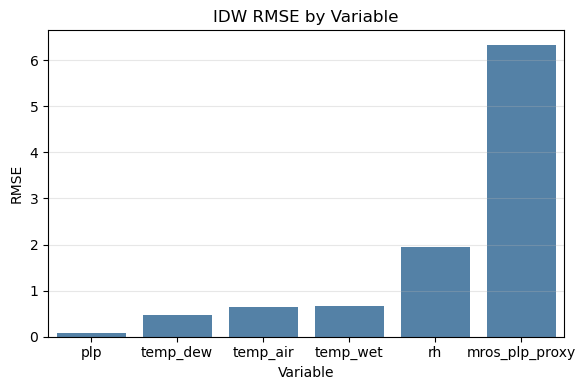

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_34848\552641057.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["var", "elev_band"])


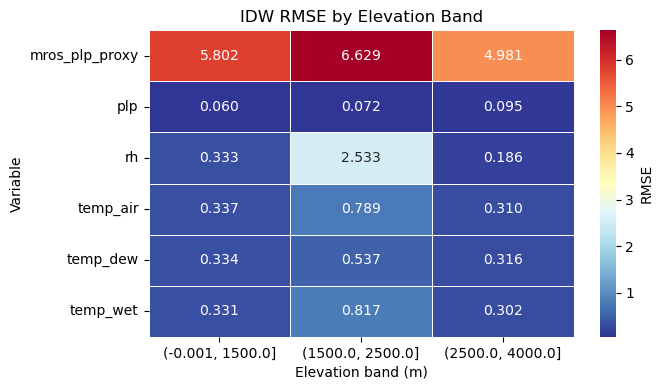

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_34848\552641057.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = pd.to_datetime(df["time"]).dt.hour


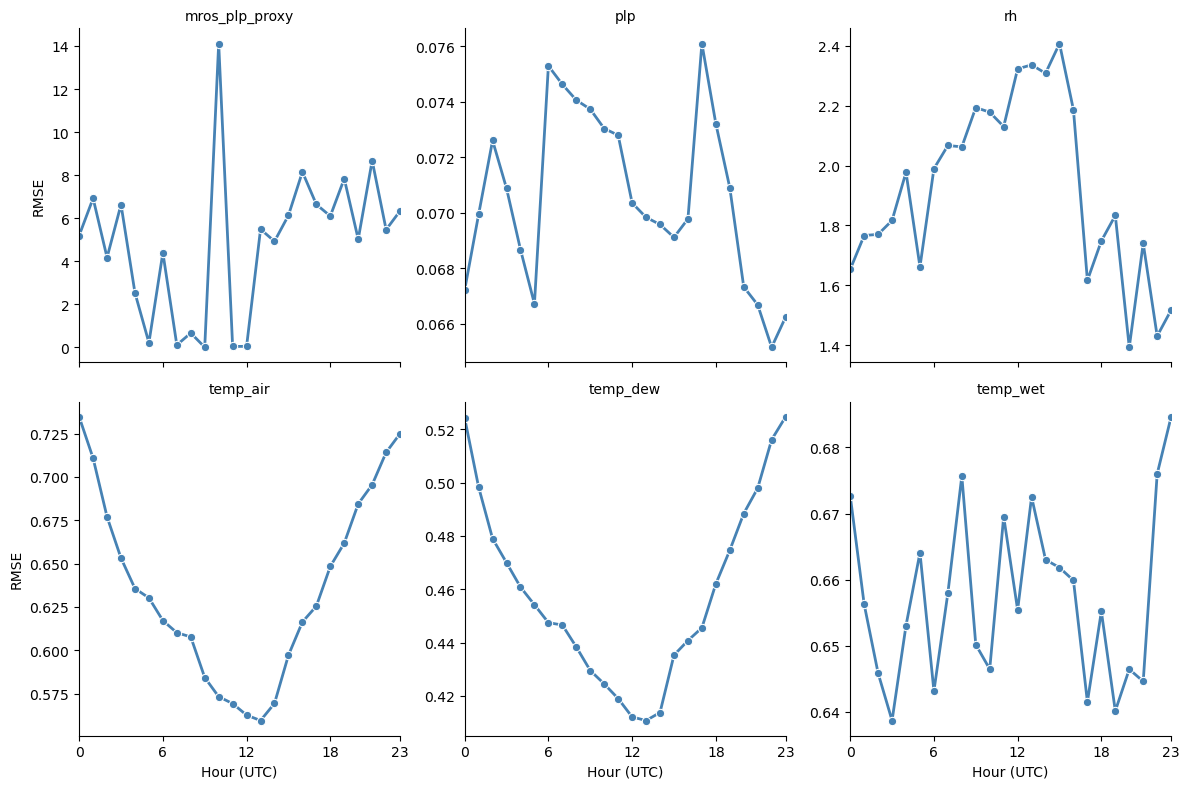

In [20]:
plot_rmse_bar(metrics, outdir=eval_dir)
plot_rmse_heatmap_by_elev(resid_df, outdir=eval_dir)
plot_rmse_by_hour(resid_df, outdir=eval_dir)
# plot_spatial_mean_residuals(resid_df, outdir=eval_dir)
# plot_residual_vs_predicted_grid(resid_df, outdir=eval_dir)
# plot_radar_summary(metrics, outdir=eval_dir)

In [21]:
idw.close()